In [1]:
!pip install pandas numpy matplotlib scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


Accuracy: 0.9917
ROC AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        66
           1       0.99      1.00      0.99       176

    accuracy                           0.99       242
   macro avg       0.99      0.98      0.99       242
weighted avg       0.99      0.99      0.99       242



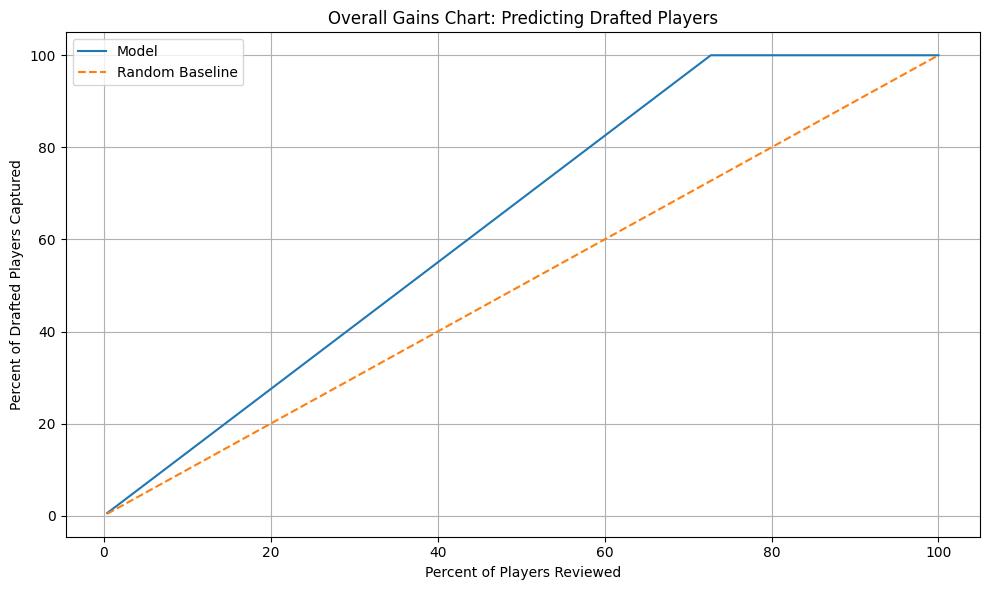

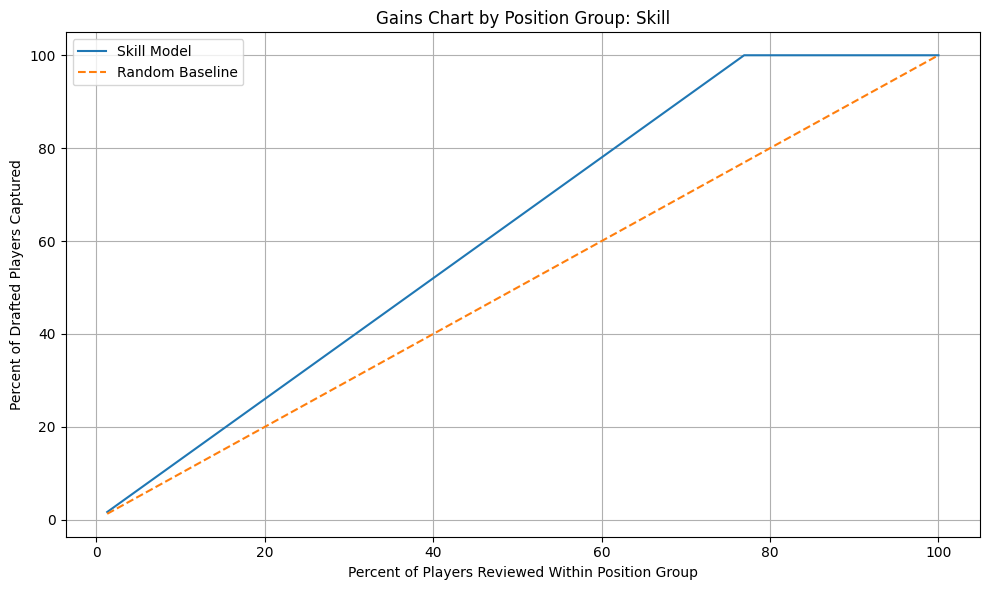

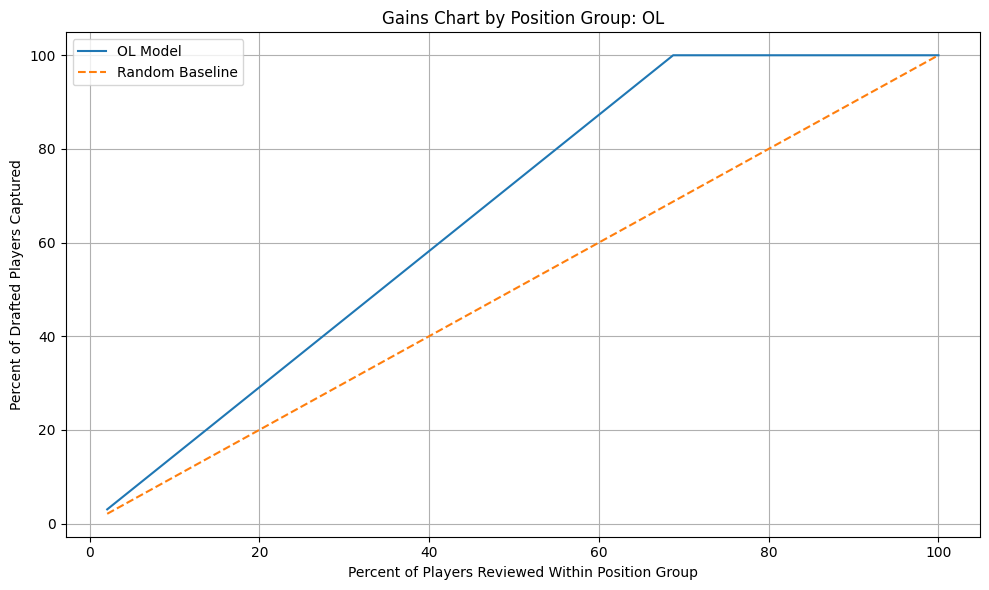

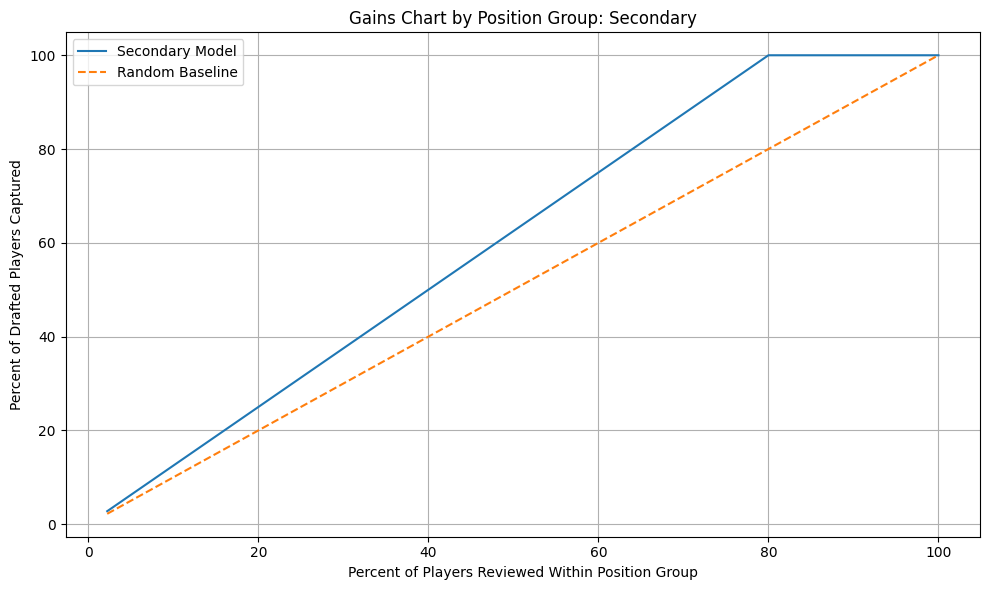

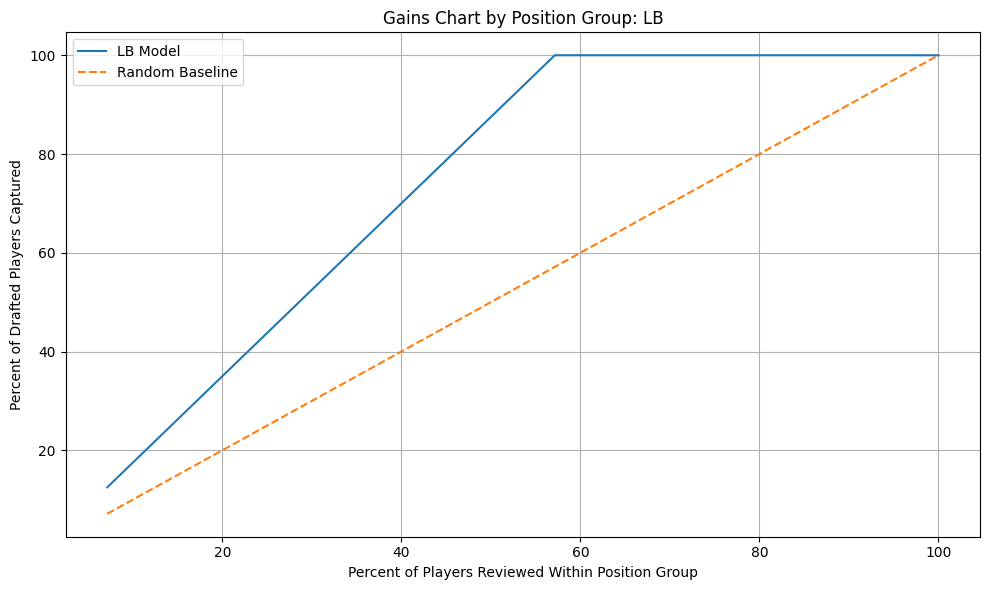

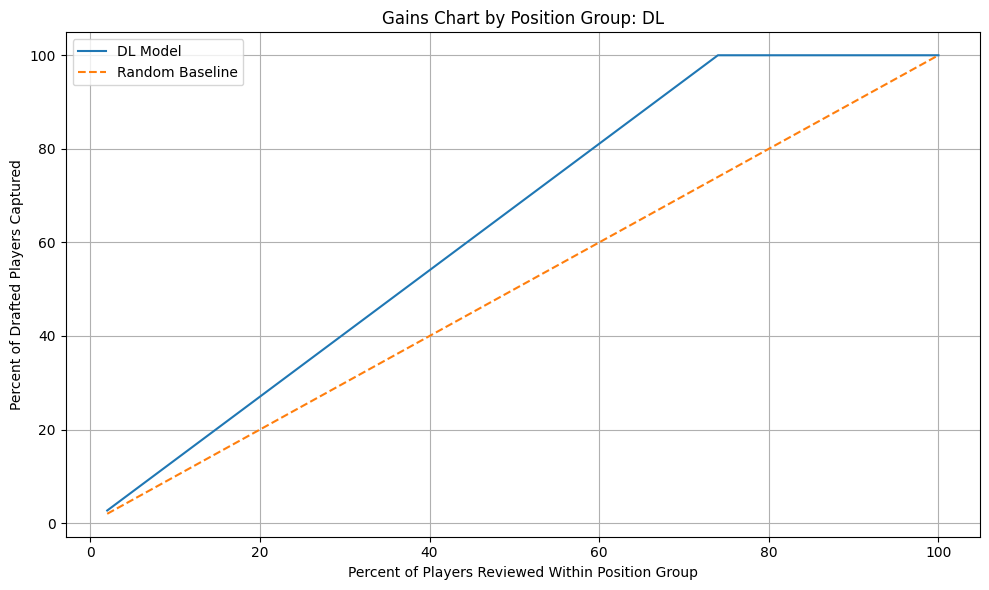

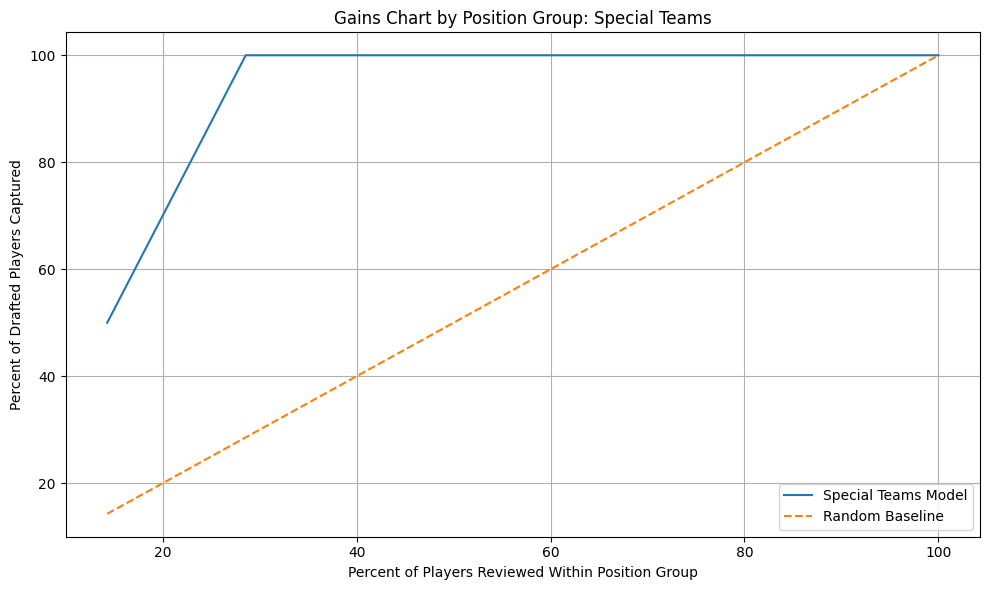

Saved: position_based_gains_chart_output.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score


# =========================
# 1. LOAD DATA
# =========================

file_path = "Post Insights Sheet(Data).csv"
df = pd.read_csv(file_path)


# =========================
# 2. CLEAN POSITION GROUPS
# =========================

position_map = {
    "QB": "Skill",
    "RB": "Skill",
    "FB": "Skill",
    "WR": "Skill",
    "TE": "Skill",

    "OT": "OL",
    "OG": "OL",
    "G": "OL",
    "C": "OL",
    "OC": "OL",
    "IOL": "OL",
    "OL": "OL",

    "EDGE": "DL",
    "DE": "DL",
    "DT": "DL",
    "DL": "DL",

    "LB": "LB",
    "ILB": "LB",
    "OLB": "LB",

    "CB": "Secondary",
    "S": "Secondary",
    "SAF": "Secondary",
    "DB": "Secondary",

    "K": "Special Teams",
    "P": "Special Teams",
    "LS": "Special Teams"
}

df["Position Group"] = df["Position"].map(position_map).fillna(df["Position"])


# =========================
# 3. TARGET VARIABLE
# =========================

df["Drafted"] = np.where(df["Overall Pick"] < 300, 1, 0)


# =========================
# 4. FEATURES
# =========================

features = [
    "Season",
    "Position",
    "Position Group",
    "School",
    "Conference",
    "Height (inches)",
    "Weight(lbs)",
    "Hand (inches)",
    "Arm (inches)",
    "Wingspan (inches)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "Combine Participation",
    "ELO",
    "FPI",
    "Efficiencies Overall",
    "Efficiencies Offense",
    "Efficiencies Defense",
    "Efficiencies SpecialTeams",
    "Log Rank",
    "CFP Appearance",
    "National Award"
]

X = df[features]
y = df["Drafted"]


categorical_features = [
    "Position",
    "Position Group",
    "School",
    "Conference"
]

numeric_features = [
    col for col in features if col not in categorical_features
]


# =========================
# 5. MODEL PIPELINE
# =========================

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=500,
            random_state=42,
            class_weight="balanced",
            min_samples_leaf=5
        ))
    ]
)


# =========================
# 6. TRAIN / TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

model.fit(X_train, y_train)


# =========================
# 7. MODEL RESULTS
# =========================

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob), 4))
print(classification_report(y_test, y_pred))


# =========================
# 8. GAINS CHART DATA
# =========================

gains_df = X_test.copy()
gains_df["Actual"] = y_test.values
gains_df["Predicted Probability"] = y_prob


# =========================
# 9. OVERALL GAINS CHART
# =========================

overall_gains = gains_df.sort_values(
    by="Predicted Probability",
    ascending=False
).reset_index(drop=True)

overall_gains["Cumulative Drafted"] = overall_gains["Actual"].cumsum()
total_drafted = overall_gains["Actual"].sum()

overall_gains["Percent of Players Reviewed"] = (
    np.arange(1, len(overall_gains) + 1) / len(overall_gains)
) * 100

overall_gains["Percent of Drafted Players Captured"] = (
    overall_gains["Cumulative Drafted"] / total_drafted
) * 100

plt.figure(figsize=(10, 6))

plt.plot(
    overall_gains["Percent of Players Reviewed"],
    overall_gains["Percent of Drafted Players Captured"],
    label="Model"
)

plt.plot(
    overall_gains["Percent of Players Reviewed"],
    overall_gains["Percent of Players Reviewed"],
    linestyle="--",
    label="Random Baseline"
)

plt.title("Overall Gains Chart: Predicting Drafted Players")
plt.xlabel("Percent of Players Reviewed")
plt.ylabel("Percent of Drafted Players Captured")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================
# 10. POSITION-GROUP GAINS CHARTS
# =========================

for group in gains_df["Position Group"].unique():
    group_df = gains_df[gains_df["Position Group"] == group].copy()

    if group_df["Actual"].sum() == 0:
        continue

    group_df = group_df.sort_values(
        by="Predicted Probability",
        ascending=False
    ).reset_index(drop=True)

    group_df["Cumulative Drafted"] = group_df["Actual"].cumsum()
    total_group_drafted = group_df["Actual"].sum()

    group_df["Percent of Players Reviewed"] = (
        np.arange(1, len(group_df) + 1) / len(group_df)
    ) * 100

    group_df["Percent of Drafted Players Captured"] = (
        group_df["Cumulative Drafted"] / total_group_drafted
    ) * 100

    plt.figure(figsize=(10, 6))

    plt.plot(
        group_df["Percent of Players Reviewed"],
        group_df["Percent of Drafted Players Captured"],
        label=f"{group} Model"
    )

    plt.plot(
        group_df["Percent of Players Reviewed"],
        group_df["Percent of Players Reviewed"],
        linestyle="--",
        label="Random Baseline"
    )

    plt.title(f"Gains Chart by Position Group: {group}")
    plt.xlabel("Percent of Players Reviewed Within Position Group")
    plt.ylabel("Percent of Drafted Players Captured")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# =========================
# 11. SAVE OUTPUT
# =========================

gains_df.to_csv("position_based_gains_chart_output.csv", index=False)

print("Saved: position_based_gains_chart_output.csv")

Dataset shape: (965, 27)

Draft Tier Counts:
Draft Tier
Undrafted     264
Rounds 6-7    230
Rounds 2-3    189
Rounds 4-5    186
Round 1        96
Name: count, dtype: int64



Accuracy: 0.8347

Classification Report:
              precision    recall  f1-score   support

     Round 1       0.68      0.88      0.76        24
  Rounds 2-3       0.67      0.72      0.69        47
  Rounds 4-5       0.83      0.64      0.72        47
  Rounds 6-7       0.89      0.88      0.89        58
   Undrafted       0.99      1.00      0.99        66

    accuracy                           0.83       242
   macro avg       0.81      0.82      0.81       242
weighted avg       0.84      0.83      0.83       242


Creating gains chart for: Round 1


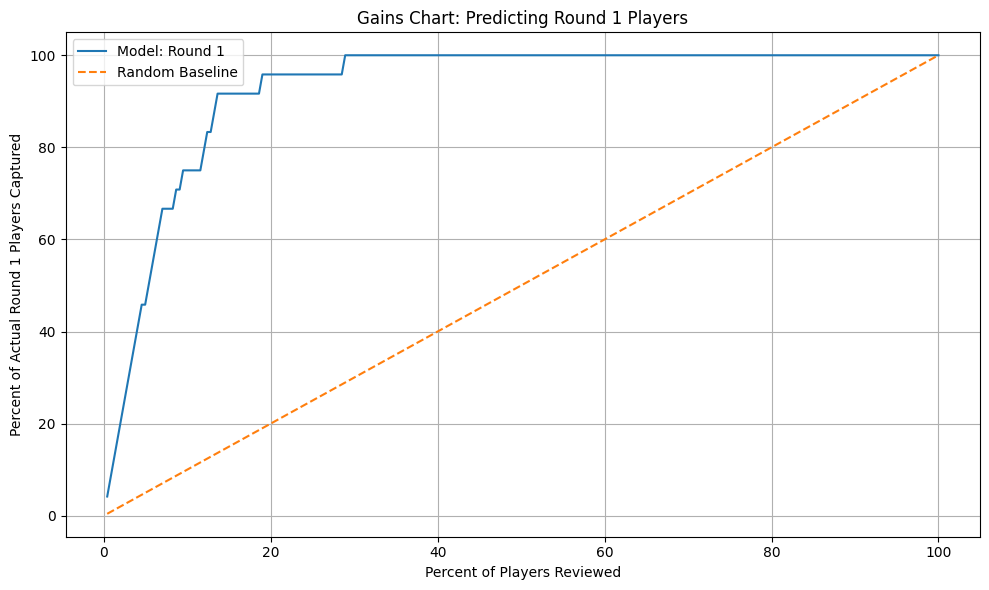


Creating gains chart for: Rounds 2-3


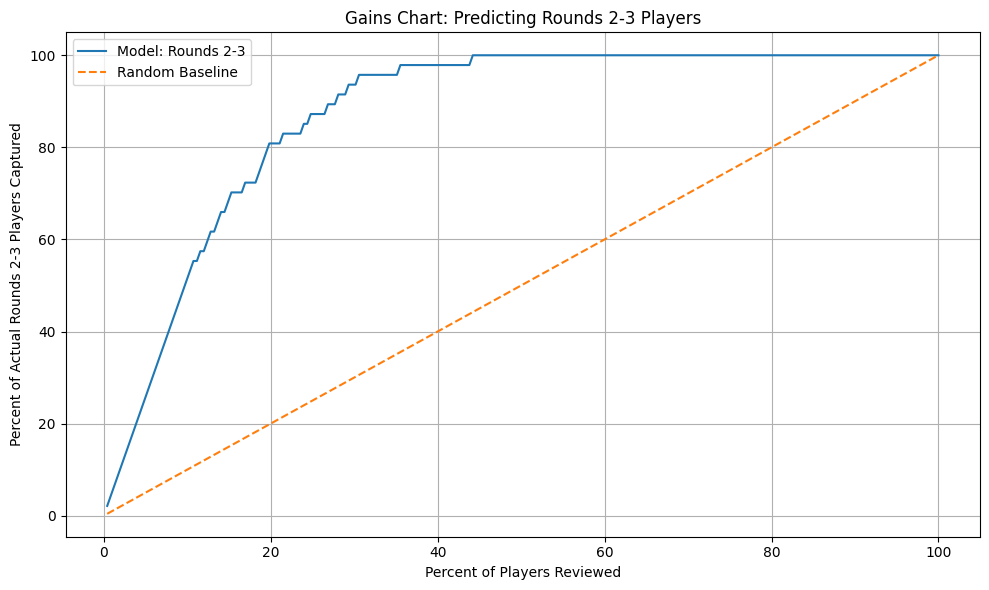


Creating gains chart for: Rounds 4-5


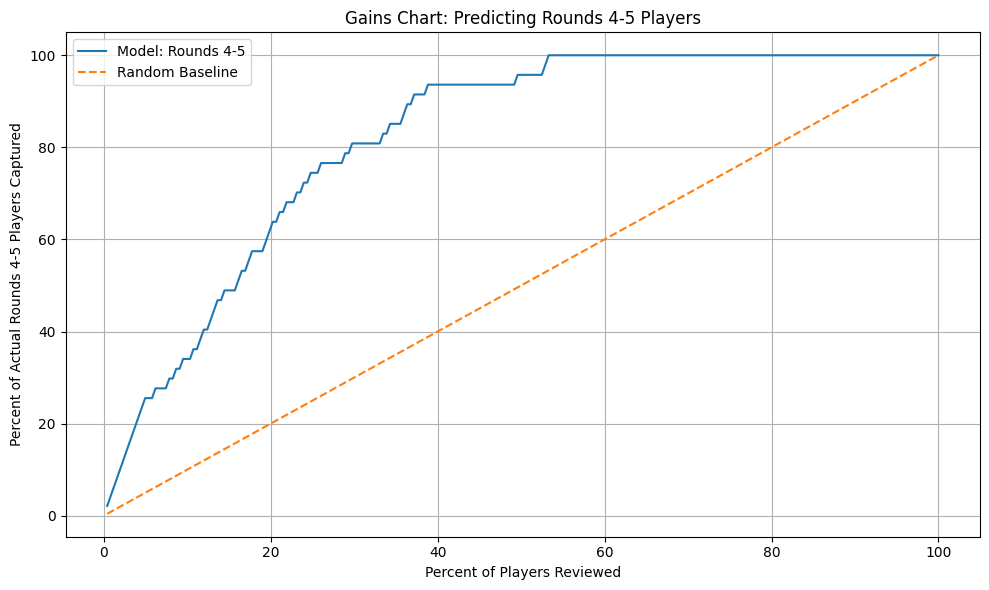


Creating gains chart for: Rounds 6-7


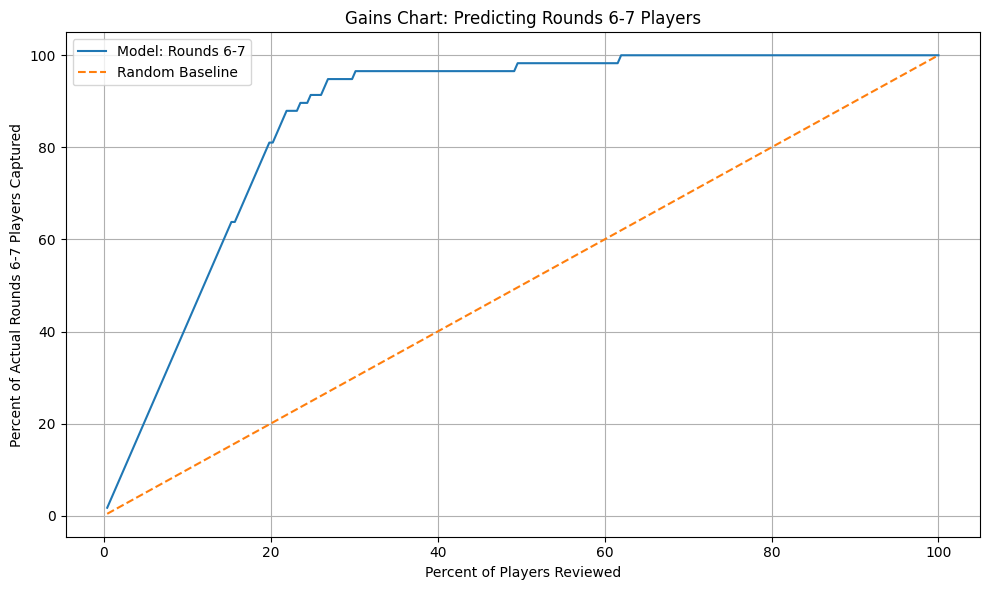


Creating gains chart for: Undrafted


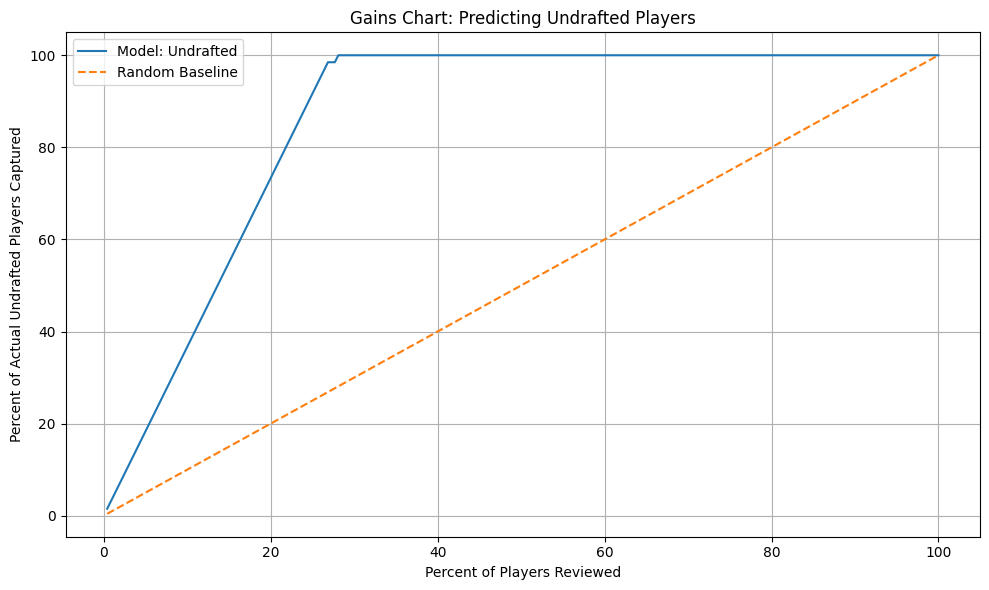


Done. Gains chart CSV files saved.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


# =========================
# 1. LOAD DATA
# =========================

file_path = "Post Insights Sheet(Data).csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)


# =========================
# 2. CREATE POSITION GROUPS
# =========================

position_map = {
    "QB": "Skill",
    "RB": "Skill",
    "FB": "Skill",
    "WR": "Skill",
    "TE": "Skill",

    "OT": "OL",
    "OG": "OL",
    "G": "OL",
    "C": "OL",
    "OC": "OL",
    "IOL": "OL",
    "OL": "OL",

    "EDGE": "DL",
    "DE": "DL",
    "DT": "DL",
    "DL": "DL",

    "LB": "LB",
    "ILB": "LB",
    "OLB": "LB",

    "CB": "Secondary",
    "S": "Secondary",
    "SAF": "Secondary",
    "DB": "Secondary",

    "K": "Special Teams",
    "P": "Special Teams",
    "LS": "Special Teams"
}

df["Position Group"] = df["Position"].map(position_map).fillna(df["Position"])


# =========================
# 3. CREATE DRAFT TIER TARGET
# =========================

def draft_tier(pick):
    if pick <= 32:
        return "Round 1"
    elif pick <= 96:
        return "Rounds 2-3"
    elif pick <= 160:
        return "Rounds 4-5"
    elif pick <= 262:
        return "Rounds 6-7"
    else:
        return "Undrafted"

df["Draft Tier"] = df["Overall Pick"].apply(draft_tier)

print("\nDraft Tier Counts:")
print(df["Draft Tier"].value_counts())


# =========================
# 4. SELECT FEATURES
# =========================
# Do not include Player, Overall Pick, or Draft Tier as predictors.

features = [
    "Season",
    "Position",
    "Position Group",
    "School",
    "Conference",
    "Height (inches)",
    "Weight(lbs)",
    "Hand (inches)",
    "Arm (inches)",
    "Wingspan (inches)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "Combine Participation",
    "ELO",
    "FPI",
    "Efficiencies Overall",
    "Efficiencies Offense",
    "Efficiencies Defense",
    "Efficiencies SpecialTeams",
    "Log Rank",
    "CFP Appearance",
    "National Award"
]

X = df[features]
y = df["Draft Tier"]


# =========================
# 5. PREPROCESSING
# =========================

categorical_features = [
    "Position",
    "Position Group",
    "School",
    "Conference"
]

numeric_features = [
    col for col in features if col not in categorical_features
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)


# =========================
# 6. TRAIN / TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


# =========================
# 7. RANDOM FOREST MODEL
# =========================

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=500,
            random_state=42,
            class_weight="balanced",
            min_samples_leaf=5
        ))
    ]
)

model.fit(X_train, y_train)


# =========================
# 8. MODEL PERFORMANCE
# =========================

y_pred = model.predict(X_test)

print("\nAccuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# =========================
# 9. PREDICT PROBABILITIES
# =========================

predicted_probs = model.predict_proba(X_test)
class_labels = model.named_steps["classifier"].classes_

prob_df = pd.DataFrame(
    predicted_probs,
    columns=class_labels
)

gains_base = X_test.copy().reset_index(drop=True)
gains_base["Actual Draft Tier"] = y_test.reset_index(drop=True)


# =========================
# 10. FUNCTION TO CREATE GAINS CHART
# =========================

def plot_gains_chart(target_tier):
    """
    Creates a gains chart for one draft tier at a time.
    Example: Round 1, Rounds 2-3, Rounds 4-5, Rounds 6-7, Undrafted
    """

    temp_df = gains_base.copy()
    temp_df["Actual Target"] = np.where(
        temp_df["Actual Draft Tier"] == target_tier,
        1,
        0
    )

    temp_df["Predicted Probability"] = prob_df[target_tier].values

    temp_df = temp_df.sort_values(
        by="Predicted Probability",
        ascending=False
    ).reset_index(drop=True)

    total_actual_targets = temp_df["Actual Target"].sum()

    if total_actual_targets == 0:
        print(f"No actual {target_tier} players in the test set.")
        return

    temp_df["Cumulative Actual Captured"] = temp_df["Actual Target"].cumsum()

    temp_df["Percent of Players Reviewed"] = (
        np.arange(1, len(temp_df) + 1) / len(temp_df)
    ) * 100

    temp_df["Percent of Actual Tier Captured"] = (
        temp_df["Cumulative Actual Captured"] / total_actual_targets
    ) * 100

    plt.figure(figsize=(10, 6))

    plt.plot(
        temp_df["Percent of Players Reviewed"],
        temp_df["Percent of Actual Tier Captured"],
        label=f"Model: {target_tier}"
    )

    plt.plot(
        temp_df["Percent of Players Reviewed"],
        temp_df["Percent of Players Reviewed"],
        linestyle="--",
        label="Random Baseline"
    )

    plt.title(f"Gains Chart: Predicting {target_tier} Players")
    plt.xlabel("Percent of Players Reviewed")
    plt.ylabel(f"Percent of Actual {target_tier} Players Captured")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return temp_df


# =========================
# 11. CREATE GAINS CHARTS FOR EACH TIER
# =========================

tier_outputs = {}

for tier in class_labels:
    print(f"\nCreating gains chart for: {tier}")
    tier_outputs[tier] = plot_gains_chart(tier)


# =========================
# 12. SAVE GAINS CHART DATA
# =========================

for tier, output_df in tier_outputs.items():
    if output_df is not None:
        clean_name = (
            tier.replace(" ", "_")
                .replace("-", "_")
                .replace("/", "_")
        )

        output_df.to_csv(
            f"gains_chart_{clean_name}.csv",
            index=False
        )

print("\nDone. Gains chart CSV files saved.")

Dataset shape: (965, 27)

Draft Round Counts:
Draft Round
Undrafted    264
Round 6      156
Round 2       96
Round 1       96
Round 4       94
Round 3       93
Round 5       92
Round 7       74
Name: count, dtype: int64



5-Fold Stratified Cross-Validation Accuracy Scores:
[0.64248705 0.72020725 0.70466321 0.65284974 0.70466321]

Average CV Accuracy:
0.685

CV Accuracy Standard Deviation:
0.0312

Test Set Accuracy:
0.7562

Full Classification Report:
              precision    recall  f1-score   support

     Round 1       0.73      0.92      0.81        24
     Round 2       0.81      0.54      0.65        24
     Round 3       0.38      0.26      0.31        23
     Round 4       0.58      0.58      0.58        24
     Round 5       0.61      0.61      0.61        23
     Round 6       0.72      0.85      0.78        39
     Round 7       0.71      0.79      0.75        19
   Undrafted       1.00      1.00      1.00        66

    accuracy                           0.76       242
   macro avg       0.69      0.69      0.69       242
weighted avg       0.75      0.76      0.75       242


Creating gains chart for: Round 1


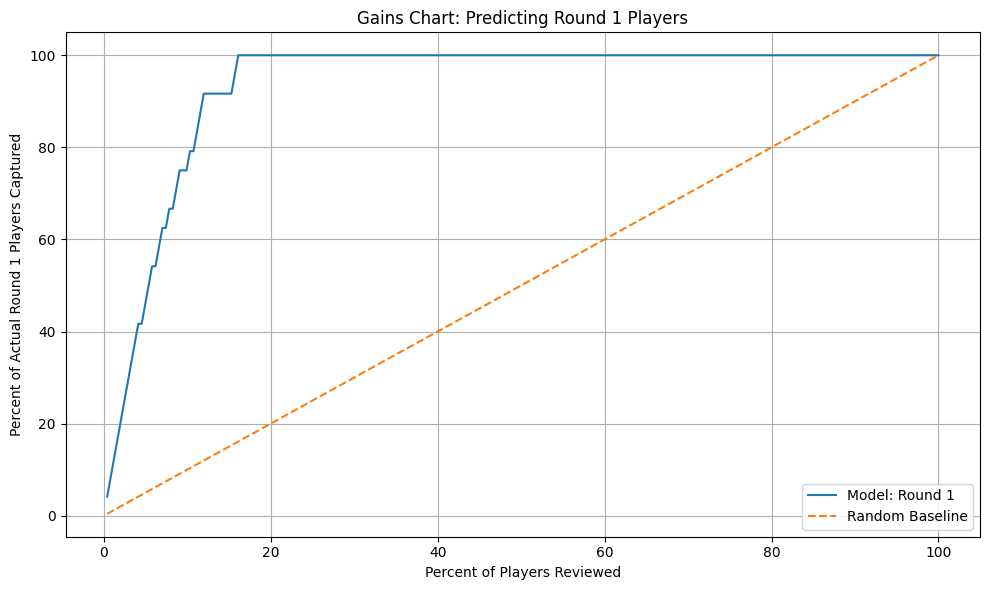


Creating gains chart for: Round 2


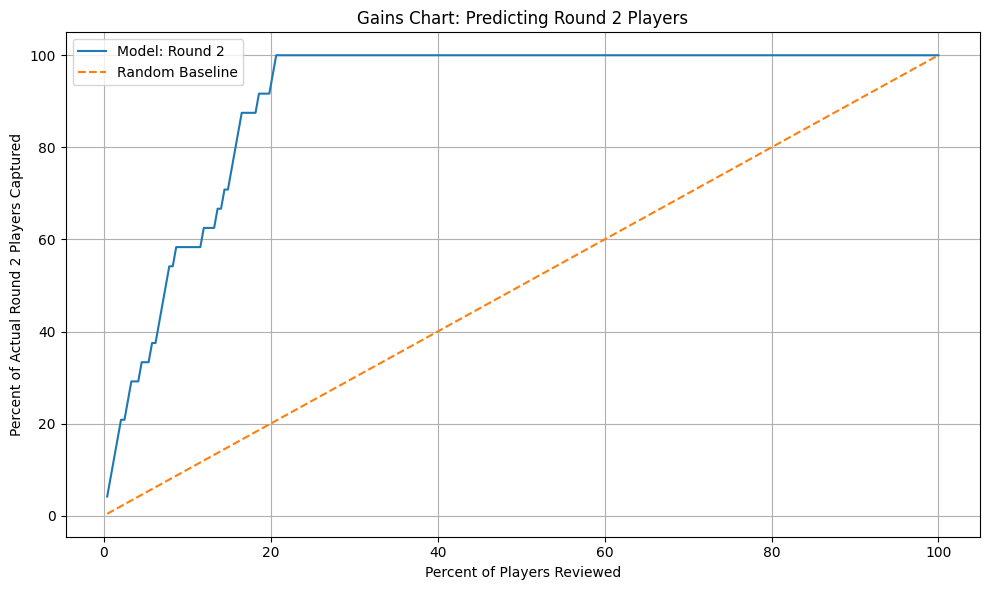


Creating gains chart for: Round 3


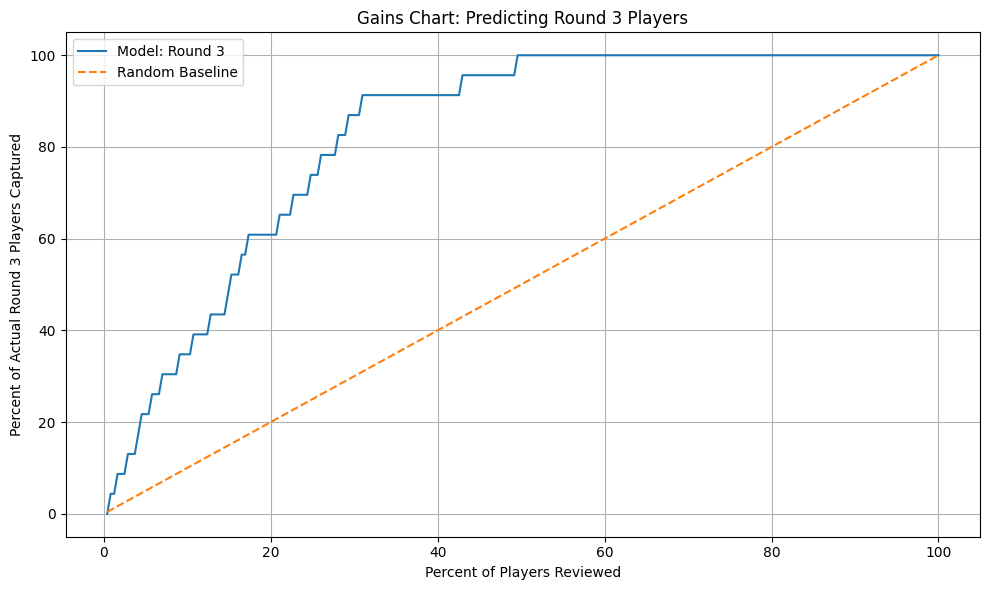


Creating gains chart for: Round 4


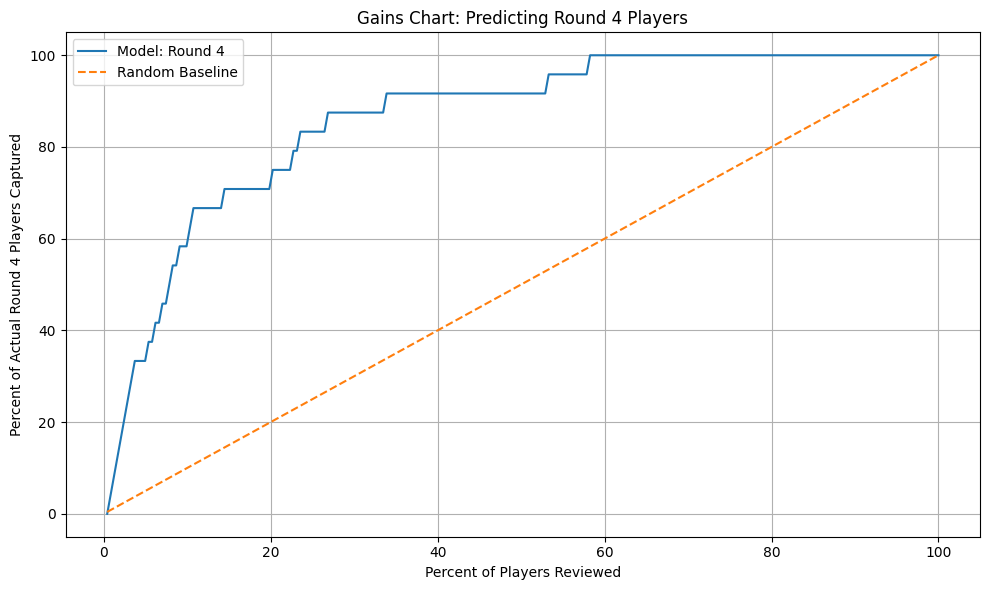


Creating gains chart for: Round 5


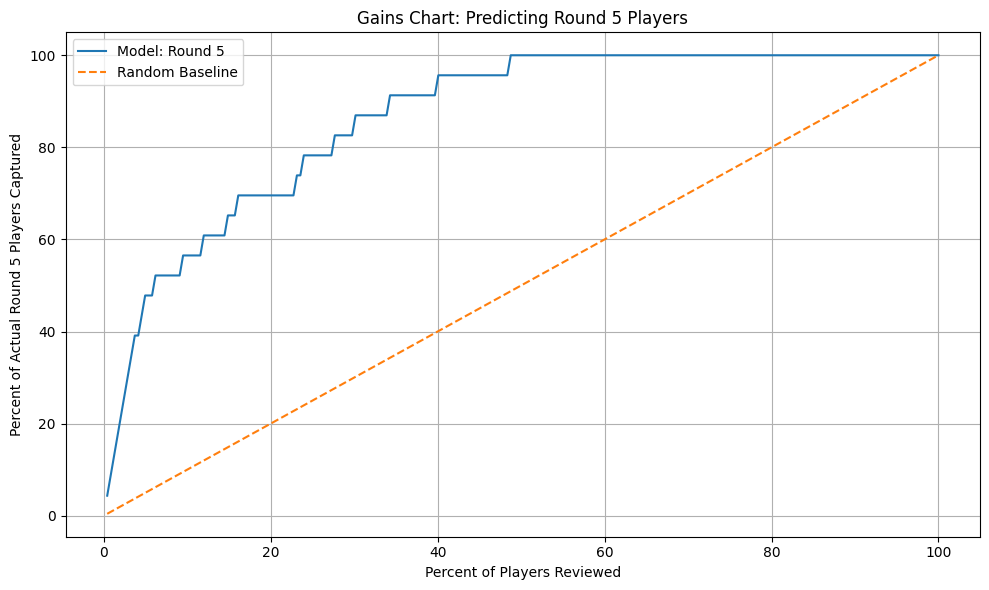


Creating gains chart for: Round 6


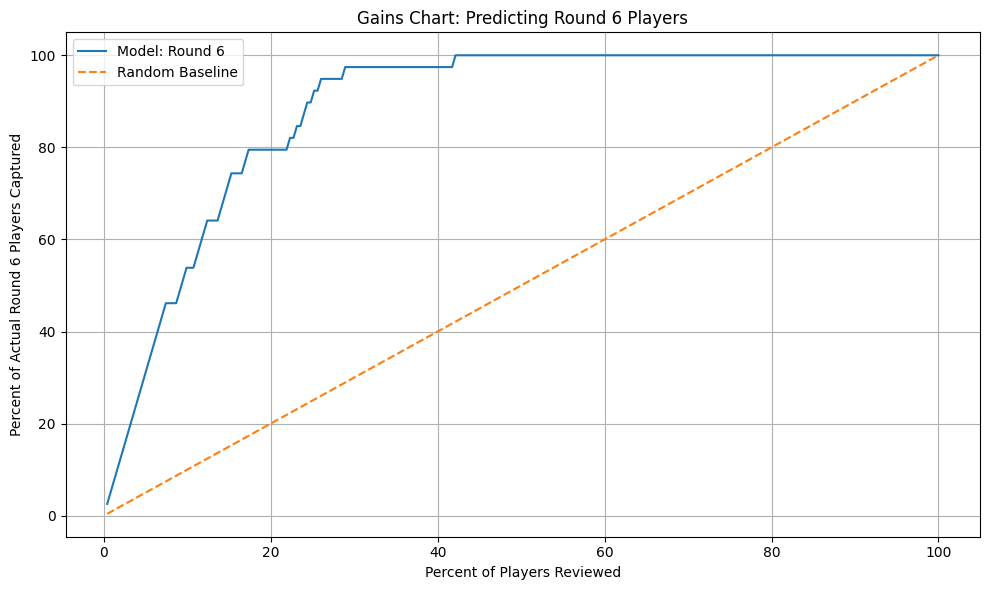


Creating gains chart for: Round 7


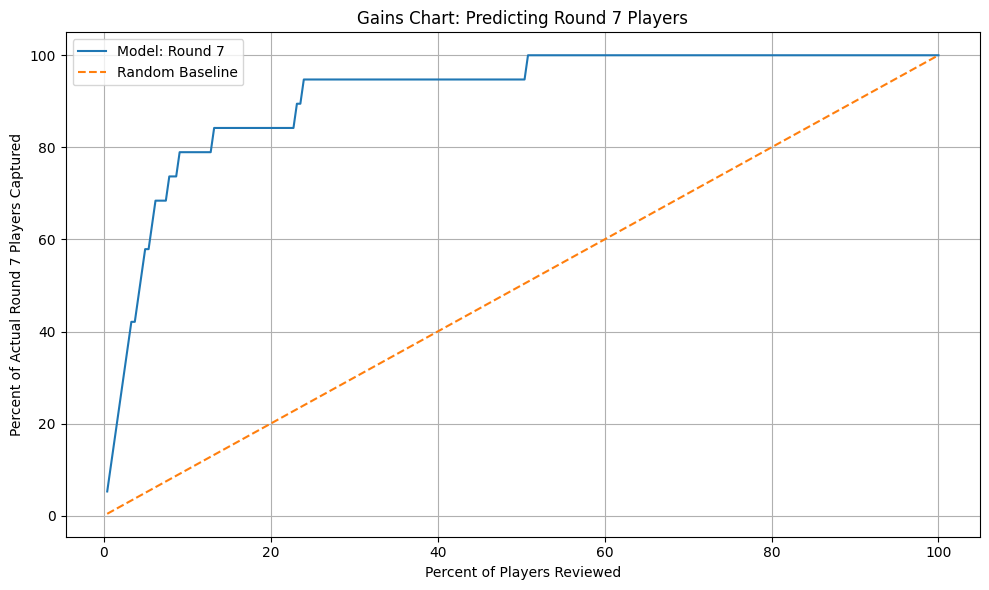


Creating gains chart for: Undrafted


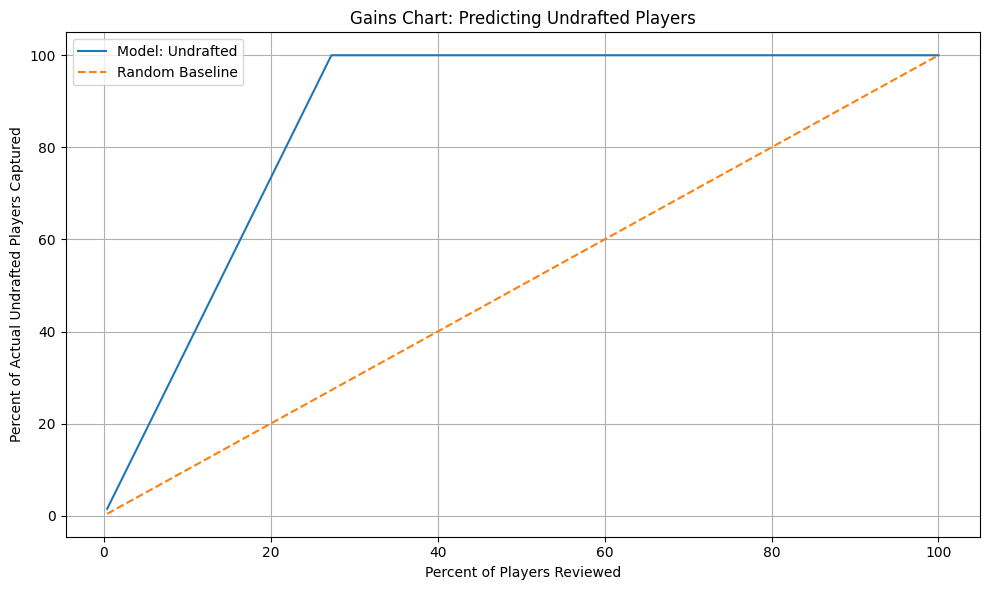


Done. Gains chart CSV files saved.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


# =========================
# 1. LOAD DATA
# =========================

file_path = "Post Insights Sheet(Data).csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)


# =========================
# 2. CREATE POSITION GROUPS
# =========================

position_map = {
    "QB": "Skill", "RB": "Skill", "FB": "Skill", "WR": "Skill", "TE": "Skill",
    "OT": "OL", "OG": "OL", "G": "OL", "C": "OL", "OC": "OL", "IOL": "OL", "OL": "OL",
    "EDGE": "DL", "DE": "DL", "DT": "DL", "DL": "DL",
    "LB": "LB", "ILB": "LB", "OLB": "LB",
    "CB": "Secondary", "S": "Secondary", "SAF": "Secondary", "DB": "Secondary",
    "K": "Special Teams", "P": "Special Teams", "LS": "Special Teams"
}

df["Position Group"] = df["Position"].map(position_map).fillna(df["Position"])


# =========================
# 3. CREATE DRAFT ROUND TARGET
# =========================

def draft_round(pick):
    if pick <= 32:
        return "Round 1"
    elif pick <= 64:
        return "Round 2"
    elif pick <= 96:
        return "Round 3"
    elif pick <= 128:
        return "Round 4"
    elif pick <= 160:
        return "Round 5"
    elif pick <= 224:
        return "Round 6"
    elif pick <= 262:
        return "Round 7"
    else:
        return "Undrafted"

df["Draft Round"] = df["Overall Pick"].apply(draft_round)

print("\nDraft Round Counts:")
print(df["Draft Round"].value_counts())


# =========================
# 4. SELECT FEATURES
# =========================

features = [
    "Season",
    "Position",
    "Position Group",
    "School",
    "Conference",
    "Height (inches)",
    "Weight(lbs)",
    "Hand (inches)",
    "Arm (inches)",
    "Wingspan (inches)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "Combine Participation",
    "ELO",
    "FPI",
    "Efficiencies Overall",
    "Efficiencies Offense",
    "Efficiencies Defense",
    "Efficiencies SpecialTeams",
    "Log Rank",
    "CFP Appearance",
    "National Award"
]

X = df[features]
y = df["Draft Round"]


# =========================
# 5. PREPROCESSING
# =========================

categorical_features = [
    "Position",
    "Position Group",
    "School",
    "Conference"
]

numeric_features = [
    col for col in features if col not in categorical_features
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)


# =========================
# 6. RANDOM FOREST MODEL
# =========================

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=500,
            random_state=42,
            class_weight="balanced",
            min_samples_leaf=5
        ))
    ]
)


# =========================
# 7. 5-FOLD STRATIFIED CROSS-VALIDATION
# =========================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("\n5-Fold Stratified Cross-Validation Accuracy Scores:")
print(cv_scores)

print("\nAverage CV Accuracy:")
print(round(cv_scores.mean(), 4))

print("\nCV Accuracy Standard Deviation:")
print(round(cv_scores.std(), 4))


# =========================
# 8. TRAIN / TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

model.fit(X_train, y_train)


# =========================
# 9. TEST SET PERFORMANCE
# =========================

y_pred = model.predict(X_test)

print("\nTest Set Accuracy:")
print(round(accuracy_score(y_test, y_pred), 4))

print("\nFull Classification Report:")

labels_order = [
    "Round 1",
    "Round 2",
    "Round 3",
    "Round 4",
    "Round 5",
    "Round 6",
    "Round 7",
    "Undrafted"
]

print(classification_report(
    y_test,
    y_pred,
    labels=labels_order,
    target_names=labels_order,
    digits=2,
    zero_division=0
))


# =========================
# 10. PREDICT PROBABILITIES
# =========================

predicted_probs = model.predict_proba(X_test)
class_labels = model.named_steps["classifier"].classes_

prob_df = pd.DataFrame(
    predicted_probs,
    columns=class_labels
)

gains_base = X_test.copy().reset_index(drop=True)
gains_base["Actual Draft Round"] = y_test.reset_index(drop=True)


# =========================
# 11. FUNCTION TO CREATE GAINS CHART
# =========================

def plot_gains_chart(target_round):
    temp_df = gains_base.copy()

    temp_df["Actual Target"] = np.where(
        temp_df["Actual Draft Round"] == target_round,
        1,
        0
    )

    temp_df["Predicted Probability"] = prob_df[target_round].values

    temp_df = temp_df.sort_values(
        by="Predicted Probability",
        ascending=False
    ).reset_index(drop=True)

    total_actual_targets = temp_df["Actual Target"].sum()

    if total_actual_targets == 0:
        print(f"No actual {target_round} players in the test set.")
        return None

    temp_df["Cumulative Actual Captured"] = temp_df["Actual Target"].cumsum()

    temp_df["Percent of Players Reviewed"] = (
        np.arange(1, len(temp_df) + 1) / len(temp_df)
    ) * 100

    temp_df["Percent of Actual Round Captured"] = (
        temp_df["Cumulative Actual Captured"] / total_actual_targets
    ) * 100

    plt.figure(figsize=(10, 6))

    plt.plot(
        temp_df["Percent of Players Reviewed"],
        temp_df["Percent of Actual Round Captured"],
        label=f"Model: {target_round}"
    )

    plt.plot(
        temp_df["Percent of Players Reviewed"],
        temp_df["Percent of Players Reviewed"],
        linestyle="--",
        label="Random Baseline"
    )

    plt.title(f"Gains Chart: Predicting {target_round} Players")
    plt.xlabel("Percent of Players Reviewed")
    plt.ylabel(f"Percent of Actual {target_round} Players Captured")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return temp_df


# =========================
# 12. CREATE GAINS CHARTS FOR EACH ROUND
# =========================

round_outputs = {}

for draft_class in labels_order:
    print(f"\nCreating gains chart for: {draft_class}")
    round_outputs[draft_class] = plot_gains_chart(draft_class)


# =========================
# 13. SAVE GAINS CHART DATA
# =========================

for draft_class, output_df in round_outputs.items():
    if output_df is not None:
        clean_name = (
            draft_class.replace(" ", "_")
                       .replace("-", "_")
                       .replace("/", "_")
        )

        output_df.to_csv(
            f"gains_chart_{clean_name}.csv",
            index=False
        )

print("\nDone. Gains chart CSV files saved.")